# Handwritten digit prediction using ANN (Keras and Tensoflow)

# load the dataset

In [1]:
from tensorflow.keras.datasets import mnist
(X_train,y_train),(X_test,y_test)=mnist.load_data()
print('Data loaded successfully')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loaded successfully


In [2]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [3]:
print(X_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

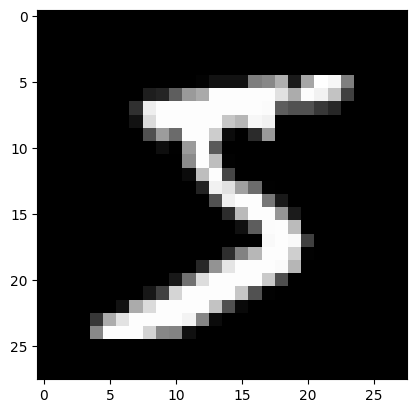

In [ ]:
# display some image from training data
import matplotlib.pyplot as plt
plt.imshow(X_train[0],cmap='gray')
plt.show()

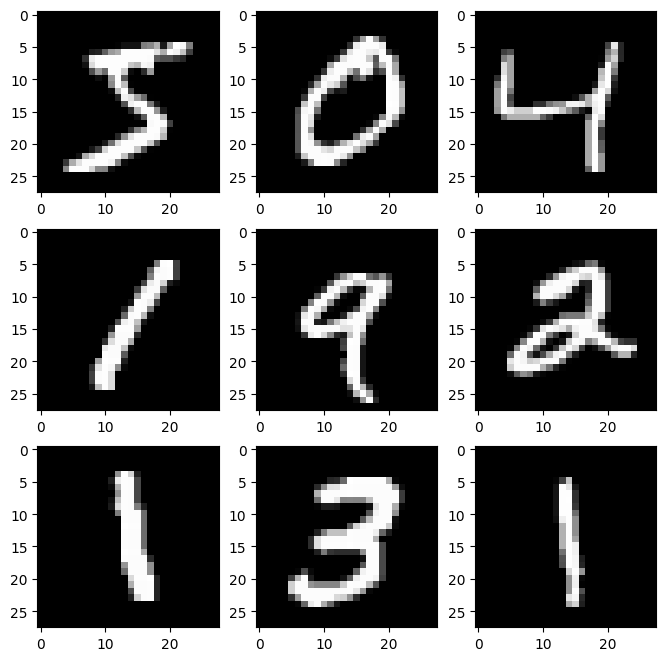

In [ ]:
# print more images using subplot use for loop
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i],cmap='gray')
    #plt.show()


In [ ]:
print(y_train[:5])

[5 0 4 1 9]


# Data Preprocessing

In [4]:
# convert 2D to one 1D
X_train=X_train.reshape(60000,784)
X_test=X_test.reshape(10000,784)

In [ ]:
X_train.shape

(60000, 784)

In [5]:
# normalize data betwen 0 to 1
X_train=X_train.astype('float32')/255
X_test=X_test.astype('float32')/255

In [ ]:
X_train.shape

(60000, 784)

In [ ]:
X_train[0].shape

(784,)

In [ ]:
print(y_train[:5])

[5 0 4 1 9]


In [6]:
# convert y into one hot encoding
from tensorflow.keras.utils import to_categorical
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [ ]:
print(y_train[:5])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


# step-
1. Create Neural Network arch (ANN)
2. Compile the NN
3. Training
4. Evalute & predict

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
print('imported')

imported


## Arch--3 hidden layer, 100 node, 64 node, 32 node, activation -Relu, op function -softmax function

In [10]:
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

In [9]:
from tensorflow.keras import regularizers

In [11]:
model=Sequential()
# first hidden layer
model.add(Dense(100,activation='relu',kernel_regularizer=regularizers.l2(0.01),input_shape=(784,)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# second hidden layer
model.add(Dense(64, kernel_regularizer=regularizers.l2(0.01),activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# third hidden layer
model.add(Dense(64, kernel_regularizer=regularizers.l2(0.01),activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# forth hidden layer
model.add(Dense(32, kernel_regularizer=regularizers.l2(0.01),activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# op layer
model.add(Dense(10, activation='softmax'))
print('model created')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


model created


In [12]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,574 (361.62 KB)

 Trainable params: 92,054 (359.59 KB)

 Non-trainable params: 520 (2.03 KB)

None


In [34]:
for layer in model.layers:
    layer_weights = layer.get_weights()
    if len(layer_weights) == 2:
        weights, biases = layer_weights
        print(f'\nLayer: {layer.name}')
        print(f'Weights shape: {weights.shape}')
        print(f'Weights: {weights}')
        print(f'Biases shape: {biases.shape}')
        print(f'Biases: {biases}')
    elif len(layer_weights) == 4:
        # BatchNormalization layers return gamma, beta, moving_mean, moving_variance
        gamma, beta, moving_mean, moving_variance = layer_weights
        print(f'\nLayer: {layer.name} (BatchNormalization)')
        print(f'Gamma shape: {gamma.shape}')
        print(f'Gamma: {gamma}')
        print(f'Beta shape: {beta.shape}')
        print(f'Beta: {beta}')
        print(f'Moving Mean shape: {moving_mean.shape}')
        print(f'Moving Mean: {moving_mean}')
        print(f'Moving Variance shape: {moving_variance.shape}')
        print(f'Moving Variance: {moving_variance}')
    else:
        print(f'\nLayer: {layer.name} has {len(layer_weights)} trainable parameters (not weights and biases).')
        if len(layer_weights) > 0:
            print(f'Parameters: {layer_weights}')


Layer: dense
Weights shape: (784, 100)
Weights: [[-2.4330993e-34 -4.3479332e-34  6.4269924e-35 ... -5.6023441e-34
  -5.4923431e-34 -4.2846365e-34]
 [-5.3846604e-34  1.0148589e-34  1.6392677e-34 ...  3.1698675e-34
  -3.2715192e-34  4.7135487e-34]
 [-4.9841769e-34  9.5803341e-35  5.2492242e-34 ...  3.3120935e-34
   4.0508027e-34 -4.3584915e-34]
 ...
 [ 4.6717057e-34 -5.3214629e-34 -6.8655448e-35 ...  5.2700667e-34
   2.1432848e-34 -1.9656589e-34]
 [ 3.0039469e-34  5.2510132e-34 -1.0092625e-34 ... -1.1855026e-34
   4.1704524e-34 -5.4872255e-34]
 [-4.0992032e-34 -5.1001669e-35 -5.3486205e-34 ...  5.5495290e-34
   2.8499723e-34 -9.5237313e-36]]
Biases shape: (100,)
Biases: [-0.04863412  0.0619715  -0.03426756  0.07026652  0.0231128   0.10350527
  0.08146643 -0.02662072 -0.04092038 -0.02009172  0.03324904 -0.08396607
 -0.03816801 -0.04966644 -0.00415548 -0.02224334 -0.04609185 -0.022603
 -0.02768133 -0.06403978 -0.0025613  -0.02338365 -0.00616467  0.02927418
  0.14240807  0.00069969 -0.0777

# Compile the NN

In [13]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
print('model compiled')

model compiled


# Train the model

### training data 60,000,

1. batch size=128 ,how many iteration req to go through whole training data, 60000/128=469..
2. Complete cycle --whole training data once -epoch
3. epochs=10

# Callbacks training
1. model checkpoint

In [14]:
import os
checkpoint_path='./checkpoints'
if not os.path.exists(checkpoint_path):
  os.makedirs(checkpoint_path)

In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [16]:
model_checkpoint=ModelCheckpoint(
    filepath=os.path.join(checkpoint_path,'best_model.keras'),monitor='val_loss',
    save_best_only=True,verbose=1
)

## EarlyStopping

In [17]:
early_stopping=EarlyStopping(monitor='val_loss',
                             patience=5, # stop training if no improvement for 5 epochs
                             mode='min',
                             min_delta=0.01, # minimum change in monitored quantity to qualify as an improvement
                             verbose=1)

In [19]:
history=model.fit(X_train,y_train,
                  batch_size=128,epochs=50,
                  validation_data=(X_test,y_test),
                  callbacks=[model_checkpoint,early_stopping])

Epoch 1/50
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6761 - loss: 3.3605
Epoch 1: val_loss improved from None to 0.87912, saving model to ./checkpoints/best_model.keras

Epoch 1: finished saving model to ./checkpoints/best_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8190 - loss: 2.1864 - val_accuracy: 0.9341 - val_loss: 0.8791
Epoch 2/50
462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9248 - loss: 0.7309
Epoch 2: val_loss improved from 0.87912 to 0.43270, saving model to ./checkpoints/best_model.keras

Epoch 2: finished saving model to ./checkpoints/best_model.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9258 - loss: 0.6252 - val_accuracy: 0.9434 - val_loss: 0.4327
Epoch 3/50
462/469 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9326 - loss: 0.4641
Epoch 3: val_loss improved from 0.43270 to 0.35075, saving model to ./checkpoints/best_model.keras

Epoch 3: finished saving model to ./checkpoints/best_model.keras
469/469 ━━━━━━━━

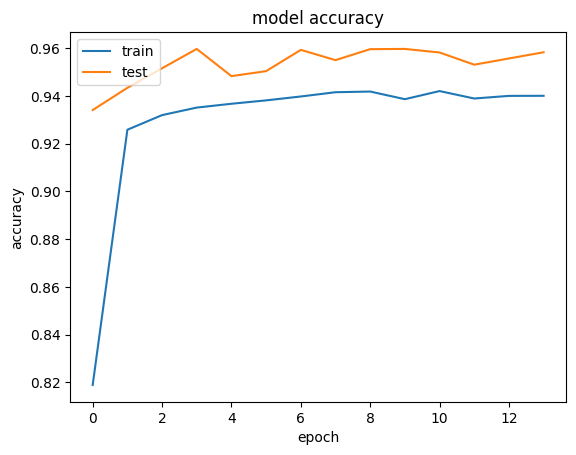

In [20]:
# plot the graph
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

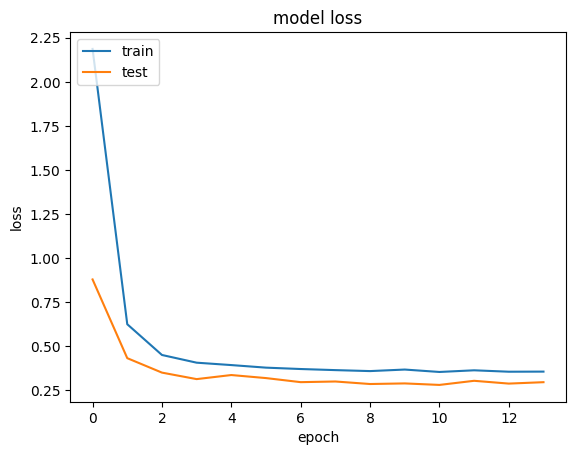

In [21]:
# plot losses
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

# Evaluate and predict

In [22]:
score=model.evaluate(X_test,y_test)
print('Test loss:',score[0])
print('Test accuracy:',score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9583 - loss: 0.2964
Test loss: 0.29644444584846497
Test accuracy: 0.958299994468689


In [23]:
#train accuracy
score=model.evaluate(X_train,y_train)
print('Train loss:',score[0])
print('Train accuracy:',score[1])
#

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9615 - loss: 0.2809
Train loss: 0.2809036374092102
Train accuracy: 0.9614666700363159


# predict

In [24]:
y_pred=model.predict(X_test)
y_pred.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


(10000, 10)

In [25]:
y_pred[0]

array([4.4711264e-06, 1.2493891e-05, 5.0579707e-05, 5.9790273e-05,
       1.4284713e-05, 2.2612705e-05, 6.3111554e-07, 9.9964428e-01,
       5.5195146e-06, 1.8529892e-04], dtype=float32)

In [26]:
import numpy as np
print(np.argmax(y_pred[0]))

7


In [27]:
y_prediction=np.argmax(y_pred,axis=1)
y_prediction[0:5]

array([7, 2, 1, 0, 4])

In [28]:
y_test[:5]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [29]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [30]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [31]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_prediction)
cm

array([[ 968,    0,    1,    1,    0,    3,    4,    1,    2,    0],
       [   0, 1115,    2,    1,    0,    0,    5,    1,   11,    0],
       [   8,    2,  987,    2,    4,    2,   11,    6,   10,    0],
       [   0,    4,    9,  967,    0,   13,    0,   13,    4,    0],
       [   2,    0,    2,    0,  940,    0,   20,    4,    1,   13],
       [   6,    1,    0,   12,    0,  849,   14,    3,    3,    4],
       [   7,    1,    0,    1,    3,    4,  940,    0,    2,    0],
       [   5,    8,   20,    2,    1,    0,    0,  988,    0,    4],
       [   6,    3,    1,    8,    5,   15,   29,    5,  899,    3],
       [  10,    8,    0,   10,   17,   15,    3,   15,    1,  930]])

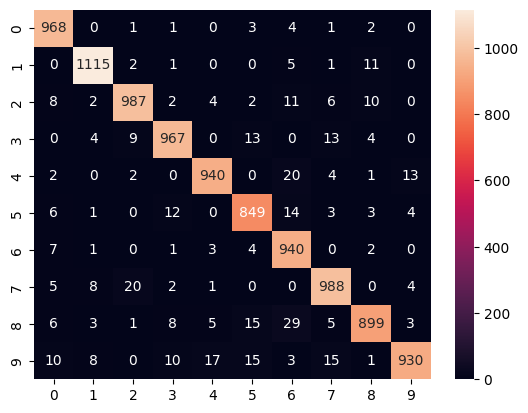

In [32]:
import seaborn as sns
sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [ ]:
# save the model
model.save('mnist_model.keras')
print('model saved')

model saved


In [ ]:
# load the model
from tensorflow.keras.models import load_model
loaded_model=load_model('mnist_model.keras')
print('model loaded successfully')

model loaded successfully


In [ ]:
print(loaded_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,124 (1023.93 KB)

 Trainable params: 87,374 (341.30 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 174,750 (682.62 KB)

None


# prediction on real data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Digit: 4


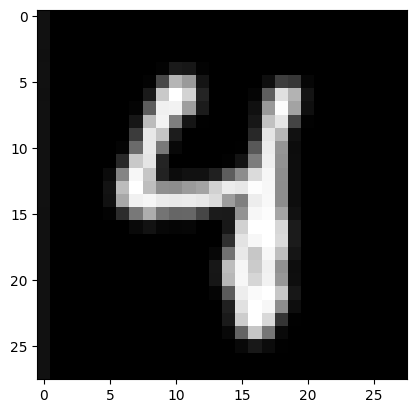

In [ ]:
import numpy as np
from PIL import Image

# Assuming 'model' is your trained neural network model

# Step 1: Preprocess the new digit image
# Load the image
new_image = Image.open('/content/n2.jfif')  # Replace 'new_digit_image.png' with the path to your image
# Convert the image to grayscale and resize it to match the input shape of your model (e.g., 28x28)
new_image = new_image.convert('L').resize((28, 28))
# Convert the image to a numpy array and normalize the pixel values
new_digit = np.array(new_image) / 255.0
# Reshape the array to match the input shape expected by the model (e.g., (1, 784) for a flattened 28x28 image)
new_digit = new_digit.reshape((1, 784))

# Step 2: Use the model to predict the digit
# Assuming 'model' is your trained model
predictions = loaded_model.predict(new_digit)

# Step 3: Interpret the predictions
# Get the predicted digit
predicted_digit = np.argmax(predictions)

# Print the predicted digit
print("Predicted Digit:", predicted_digit)

# plot the image
plt.imshow(new_digit.reshape(28, 28), cmap='gray')
plt.show()

